In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import re
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
class ConditioningLabeler:
    """
    Turns conditioning codenames like:
        'pipimdqidpiririm'  ->  r_{n+1} | v_n, v_{n-1}, Δx_n, Δv_n, r_n, r_{n-1}
        'pipimri'           ->  r_{n+1} | v_n, v_{n-1}, r_n
        'piririm'           ->  r_{n+1} | v_n, r_n, r_{n-1}

    Token grammar (extendable):
      pi      -> v_n
      pim     -> v_{n-1}
      pimm    -> v_{n-2}
      dqi     -> Δx_n
      dqim    -> Δx_{n-1}      (if you ever use it)
      dpi     -> Δv_n
      dpim    -> Δv_{n-1}      (if you ever use it)
      ri      -> r_n
      rim     -> r_{n-1}
      rimm    -> r_{n-2}
    """
    # Order matters: longest tokens first to avoid partial matches (e.g. "pimm" before "pim")
    _token_specs = [
        ("pimm",  r"v_{n-2}"),
        ("pim",   r"v_{n-1}"),
        ("pi",    r"v_n"),
        ("dqim",  r"\Delta x_{n-1}"),
        ("dqi",   r"\Delta x_n"),
        ("dpim",  r"\Delta v_{n-1}"),
        ("dpi",   r"\Delta v_n"),
        ("rimm",  r"r_{n-2}"),
        ("rim",   r"r_{n-1}"),
        ("ri",    r"r_n"),
    ]

    def __init__(self, target: str = r"r_{n+1}"):
        self.target = target
        # compile regex that matches any known token (longest-first)
        toks = [re.escape(t[0]) for t in self._token_specs]
        self._pattern = re.compile("|".join(toks))

        self._map = {tok: label for tok, label in self._token_specs}

    def tokenize(self, codename: str) -> list[str]:
        """
        Split codename into known tokens.
        Raises ValueError if any characters remain unmatched.
        """
        tokens = self._pattern.findall(codename)
        joined = "".join(tokens)
        if joined != codename:
            # find first mismatch location for a helpful error
            i = 0
            for t in tokens:
                i += len(t)
            raise ValueError(f"Unknown token sequence in '{codename}'. Parsed '{joined}', remaining '{codename[len(joined):]}'")
        return tokens

    def tokens_to_labels(self, tokens: list[str]) -> list[str]:
        return [self._map[t] for t in tokens]

    def make_label(self, codename: str, *, latex: bool = True) -> str:
        """
        Returns label like:
          latex=True  -> r_{n+1} \mid v_n, v_{n-1}, ...
          latex=False -> r_(n+1) | v_n, v_(n-1), ...
        """
        tokens = self.tokenize(codename)
        conds = self.tokens_to_labels(tokens)

        if latex:
            return rf"{self.target} \mid " + ", ".join(conds)
        else:
            # quick plaintext fallback
            plain = [
                c.replace(r"\Delta", "Δ").replace("{", "").replace("}", "")
                for c in conds
            ]
            target_plain = self.target.replace("{", "").replace("}", "")
            return f"{target_plain} | " + ", ".join(plain)


<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_67773/1133567231.py:61: SyntaxWarning: invalid escape sequence '\m'
  """


In [4]:
lab = ConditioningLabeler()
print(lab.make_label("pipimdqidpiririm"))
print(lab.make_label("pipimri"))
print(lab.make_label("piririm"))


r_{n+1} \mid v_n, v_{n-1}, \Delta x_n, \Delta v_n, r_n, r_{n-1}
r_{n+1} \mid v_n, v_{n-1}, r_n
r_{n+1} \mid v_n, r_n, r_{n-1}


In [5]:
# ============================================================
# 0) Path helpers (4-digit zero padding + your directory layout)
# ============================================================

def z4(i: int) -> str:
    return f"{int(i):04d}"

def benchmark_path(baseDirPath: str, bench_fileID: int, boxsize: int | float = 5) -> str:
    # /.../dimer/boxsize5/benchmark/simMoriZwanzig_XXXX.h5
    return os.path.join(
        baseDirPath,
        f"dimer/boxsize{boxsize}/benchmark/simMoriZwanzig_{z4(bench_fileID)}.h5"
    )

def reduced_path(baseDirPath: str, conditionedOn: str, reduc_fileID: int, boxsize: int | float = 5) -> str:
    # /.../dimerGlobal/boxsize5/benchmarkReducedGen_{cond}/simMoriZwanzigReduced_XXXX.h5
    return os.path.join(
        baseDirPath,
        f"dimerGlobal/boxsize{boxsize}/benchmarkReducedGen_{conditionedOn}/simMoriZwanzigReduced_{z4(reduc_fileID)}.h5"
    )

# ============================================================
# 1) Loading (benchmark: key='msmrd_data' D=11; reduced: key='trajectory' D=10)
# ============================================================

def load_dimer_h5(path: str, key: str) -> dict:
    """
    Loads a flat dataset with alternating bead rows:
      X shape = (2*T, D), alternating bead 0 / bead 1 rows.

    Supported layouts:
      - D = 11: [t, q(3), v(3), mystery(1), r(3)]  -> r at 8:11
      - D = 10: [t, q(3), v(3), r(3)]              -> r at 7:10

    Returns dict with:
      t: (T,)
      q: (T,2,3)
      v: (T,2,3)
      r: (T,2,3)
      T, D
    """
    with h5py.File(path, "r") as f:
        X = f[key][:]

    if X.ndim != 2 or (X.shape[0] % 2 != 0):
        raise ValueError(f"Expected (2*T, D) dataset at '{key}', got {X.shape} in {path}")

    D = X.shape[1]
    if D not in (10, 11):
        raise ValueError(f"Expected D=10 or D=11 columns, got D={D} in {path}")

    T = X.shape[0] // 2
    frames = X.reshape(T, 2, D)

    t = frames[:, 0, 0]
    q = frames[:, :, 1:4]
    v = frames[:, :, 4:7]
    r = frames[:, :, 8:11] if D == 11 else frames[:, :, 7:10]

    return dict(t=t, q=q, v=v, r=r, T=T, D=D)

# ============================================================
# 2) PBC minimal-image + derived quantities
# ============================================================

def minimal_image_rel_np(rel: np.ndarray, boxsize, boundary_type: str = "periodic") -> np.ndarray:
    if boundary_type != "periodic" or boxsize is None:
        return rel

    box = np.asarray(boxsize, dtype=rel.dtype)
    if box.size == 1:
        box = np.repeat(box, 3)
    if box.size != 3:
        raise ValueError(f"boxsize must be scalar or length-3, got {box}")

    return rel - box * np.round(rel / box)

def unwrap_positions(R: np.ndarray, boxsize) -> np.ndarray:
    """
    Unwrap a wrapped trajectory R(t) in a periodic box using minimal-image increments.

    R: (T,3) wrapped positions in [-L/2,L/2] or [0,L] (either is fine for increments)
    boxsize: scalar or length-3
    returns: (T,3) unwrapped positions
    """
    R = np.asarray(R)
    box = np.asarray(boxsize, dtype=R.dtype)
    if box.size == 1:
        box = np.repeat(box, 3)
    if box.size != 3:
        raise ValueError(f"boxsize must be scalar or length-3, got {box}")

    dR = np.diff(R, axis=0)                         # (T-1,3)
    dR_mi = dR - box * np.round(dR / box)           # minimal-image step increments

    R_unwrap = np.empty_like(R)
    R_unwrap[0] = R[0]
    R_unwrap[1:] = R_unwrap[0] + np.cumsum(dR_mi, axis=0)
    return R_unwrap

def compute_dimer_observables(q: np.ndarray, boxsize=None, boundary_type: str = "periodic") -> dict:
    """
    q: (T,2,3)
    Returns:
      R:    (T,3) COM
      rel:  (T,3) minimal-image bond vector
      bond: (T,)  bond length
      u:    (T,3) orientation unit vector
    """
    if q.ndim != 3 or q.shape[1:] != (2, 3):
        raise ValueError(f"Expected q shape (T,2,3), got {q.shape}")

    R = 0.5 * (q[:, 0, :] + q[:, 1, :])
    rel_raw = q[:, 1, :] - q[:, 0, :]
    rel = minimal_image_rel_np(rel_raw, boxsize, boundary_type=boundary_type)
    bond = np.linalg.norm(rel, axis=1)
    u = rel / np.maximum(bond[:, None], 1e-12)
    return dict(R=R, rel=rel, bond=bond, u=u)

def compute_rotational_momentum(q: np.ndarray, v: np.ndarray, boxsize=None):
    """
    q, v: (T,2,3)
    returns:
      L: (T,3)   kinematic angular momentum r x v_rel
      Lmag: (T,) magnitude |L|
    """
    # relative position (PBC)
    rel = q[:, 1, :] - q[:, 0, :]
    rel = minimal_image_rel_np(rel, boxsize)

    # relative velocity (no PBC needed)
    vrel = v[:, 1, :] - v[:, 0, :]

    L = np.cross(rel, vrel)
    Lmag = np.linalg.norm(L, axis=1)
    return L, Lmag

# ============================================================
# 3) Diagnostics: MSD + orientational ACF (per-trajectory)
# ============================================================

def msd_simple(R: np.ndarray, max_lag: int = 2000) -> tuple[np.ndarray, np.ndarray]:
    T = R.shape[0]
    max_lag = min(max_lag, T - 1)
    lags = np.arange(1, max_lag + 1)
    out = np.empty_like(lags, dtype=float)
    for i, lag in enumerate(lags):
        d = R[lag:] - R[:-lag]
        out[i] = np.mean(np.sum(d * d, axis=1))
    return lags, out

def orient_acf(u: np.ndarray, max_lag: int = 2000) -> tuple[np.ndarray, np.ndarray]:
    T = u.shape[0]
    max_lag = min(max_lag, T - 1)
    lags = np.arange(0, max_lag + 1)
    C = np.empty_like(lags, dtype=float)
    for i, lag in enumerate(lags):
        C[i] = np.mean(np.sum(u[:T - lag] * u[lag:], axis=1))
    return lags, C

# ============================================================
# 4) Snippet selection for reduced trajectories
# ============================================================

def take_snippet(data: dict, T_target: int, rng: np.random.Generator) -> dict:
    """
    Takes a random contiguous snippet of length T_target from data dict (t,q,v,r).
    Assumes data has at least T_target frames.
    """
    T = data["T"]
    if T < T_target:
        raise ValueError(f"Trajectory too short: T={T} < T_target={T_target}")

    start = int(rng.integers(0, T - T_target + 1))
    sl = slice(start, start + T_target)

    out = dict(data)  # shallow copy
    for k in ("t", "q", "v", "r"):
        out[k] = out[k][sl]
    out["T"] = T_target
    out["_snippet_start"] = start
    return out

# ============================================================
# 5) Ensemble comparison: average over many trajectories
# ============================================================

def compare_dimer_h5_ensemble(
    bench_fileIDs: np.ndarray,
    reduc_fileIDs: np.ndarray,
    *,
    baseDirPath: str,
    conditionedOn: str,
    boxsize: float = 5.0,                 # for PBC + for path construction
    boundary_type: str = "periodic",
    key_benchmark: str = "msmrd_data",
    key_reduced: str = "trajectory",
    reduced_plot_mode: str = "snippet",   # "snippet" or "full"
    random_seed: int | None = 0,
    max_lag: int = 2000,
    n_com_overlay: int = 1,          # how many COM trajectories to overlay for intuition
):
    """
    Loads many benchmark + reduced trajectories and produces *ensemble-averaged* plots:
      - mean bond(t) +/- std
      - mean orientation ACF +/- std
      - mean MSD(COM) +/- std
      - COM (x-y) overlay of a few sample paths (qualitative; average path isn't meaningful)

    reduced_plot_mode:
      - "snippet": for each reduced trajectory, take a random contiguous snippet of length equal to benchmark length
      - "full":    use full reduced trajectories (plots that require equal length are truncated to common min length)
    """
    rng = np.random.default_rng(random_seed)
    labeler = ConditioningLabeler(target=r"r_{n+1}")
    cond_label = labeler.make_label(conditionedOn, latex=True)


    # ---------- load benchmark ----------
    bench_datas = []
    bench_failed = []
    for fid in bench_fileIDs:
        p = benchmark_path(baseDirPath, fid, boxsize=boxsize)
        try:
            d = load_dimer_h5(p, key_benchmark)
            bench_datas.append(d)
        except Exception as e:
            bench_failed.append((fid, str(e)))

    if len(bench_datas) == 0:
        raise RuntimeError(f"No benchmark trajectories loaded. First error: {bench_failed[:1]}")

    # define benchmark target length for comparison
    T_bench = bench_datas[0]["T"]
    # if there are slight inconsistencies, truncate all to min
    T_bench = min(T_bench, *(d["T"] for d in bench_datas))
    for i in range(len(bench_datas)):
        if bench_datas[i]["T"] != T_bench:
            sl = slice(0, T_bench)
            for k in ("t", "q", "v", "r"):
                bench_datas[i][k] = bench_datas[i][k][sl]
            bench_datas[i]["T"] = T_bench

    # ---------- load reduced ----------
    reduc_datas = []
    reduc_failed = []
    for fid in reduc_fileIDs:
        p = reduced_path(baseDirPath, conditionedOn, fid, boxsize=boxsize)
        try:
            d = load_dimer_h5(p, key_reduced)
            reduc_datas.append(d)
        except Exception as e:
            reduc_failed.append((fid, str(e)))

    if len(reduc_datas) == 0:
        raise RuntimeError(f"No reduced trajectories loaded. First error: {reduc_failed[:1]}")

    # apply snippet / full logic to reduced
    if reduced_plot_mode not in ("snippet", "full"):
        raise ValueError("reduced_plot_mode must be 'snippet' or 'full'")

    if reduced_plot_mode == "snippet":
        # each reduced traj gets its own random snippet matching benchmark length
        reduc_datas = [take_snippet(d, T_bench, rng) for d in reduc_datas]
        T_reduc_used = T_bench
    else:
        # full mode: we can still only average bond(t) up to common min length with benchmark,
        # otherwise time-series averaging is ill-defined.
        T_reduc_used = min(*(d["T"] for d in reduc_datas))
        T_common = min(T_bench, T_reduc_used)
        # truncate benchmark and reduced to common length for bond(t) comparisons
        if T_common != T_bench:
            for i in range(len(bench_datas)):
                sl = slice(0, T_common)
                for k in ("t", "q", "v", "r"):
                    bench_datas[i][k] = bench_datas[i][k][sl]
                bench_datas[i]["T"] = T_common
            T_bench = T_common
        if T_common != T_reduc_used:
            for i in range(len(reduc_datas)):
                sl = slice(0, T_common)
                for k in ("t", "q", "v", "r"):
                    reduc_datas[i][k] = reduc_datas[i][k][sl]
                reduc_datas[i]["T"] = T_common
            T_reduc_used = T_common

    # ---------- compute per-trajectory observables ----------
    def compute_all(datas, desc="Computing observables"):
        bonds = []
        Lmag_all = []
        msds = []
        oacfs = []
        com_paths = []

        for d in tqdm(datas, desc=desc, leave=True):
            obs = compute_dimer_observables(d["q"], boxsize=boxsize, boundary_type=boundary_type)
            bonds.append(obs["bond"])
            #com_paths.append(obs["R"])
            R = obs["R"]
            R_unwrap = unwrap_positions(R, boxsize=boxsize)
            com_paths.append(R_unwrap)


            L, Lmag = compute_rotational_momentum(d["q"], d["v"], boxsize=boxsize)
            Lmag_all.append(Lmag)

            l_msd, msd = msd_simple(obs["R"], max_lag=max_lag)
            l_o, oacf = orient_acf(obs["u"], max_lag=max_lag)

            msds.append(msd)
            oacfs.append(oacf)

        bonds     = np.stack(bonds, axis=0)        # (N,T)
        Lmag_all  = np.stack(Lmag_all, axis=0)     # (N,T)
        msds      = np.stack(msds, axis=0)         # (N,max_lag)
        oacfs     = np.stack(oacfs, axis=0)        # (N,max_lag+1)

        return bonds, Lmag_all, msds, oacfs, com_paths, l_msd, l_o


    bonds_A, Lmag_A, msd_A, oacf_A, com_A, l_msd, l_o = compute_all(bench_datas, desc='Computing benchmark observables')
    bonds_B, Lmag_B, msd_B, oacf_B, com_B, _, _       = compute_all(reduc_datas, desc='Computing reduced observables')

    # ensemble stats
    def mean_std(x):
        return x.mean(axis=0), x.std(axis=0)

    bondA_mu, bondA_sd = mean_std(bonds_A)
    bondB_mu, bondB_sd = mean_std(bonds_B)

    LmagA_mu, LmagA_sd = mean_std(Lmag_A)
    LmagB_mu, LmagB_sd = mean_std(Lmag_B)

    msdA_mu, msdA_sd = mean_std(msd_A)
    msdB_mu, msdB_sd = mean_std(msd_B)

    oacfA_mu, oacfA_sd = mean_std(oacf_A)
    oacfB_mu, oacfB_sd = mean_std(oacf_B)

    # time axes (use first loaded traj; lengths now consistent)
    tA = bench_datas[0]["t"]
    tB = reduc_datas[0]["t"]

    # ---------- PLOTTING ----------
    figs = {}

    fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex="col")

    # === time averages ===
    bondA_bar = bondA_mu.mean()
    bondB_bar = bondB_mu.mean()
    LmagA_bar = LmagA_mu.mean()
    LmagB_bar = LmagB_mu.mean()

    # --- Bond length ---
    ax[0, 0].plot(tA, bondA_mu)
    ax[0, 0].fill_between(tA, bondA_mu - bondA_sd, bondA_mu + bondA_sd, alpha=0.25)
    ax[0, 0].axhline(bondA_bar, ls="--", lw=1.5)
    ax[0, 0].set_title("Benchmark: ⟨bond(t)⟩ ± std")
    ax[0, 0].set_ylabel("bond length (nm)")

    ax[0, 1].plot(tB, bondB_mu)
    ax[0, 1].fill_between(tB, bondB_mu - bondB_sd, bondB_mu + bondB_sd, alpha=0.25)
    ax[0, 1].axhline(bondB_bar, ls="--", lw=1.5)
    ax[0, 1].set_title(rf"Reduced ({reduced_plot_mode}): $\langle bond(t)\rangle \pm std$" + "\n" + rf"$ {cond_label} $")
    ax[0, 1].sharey(ax[0, 0])

    # --- Rotational momentum magnitude ---
    ax[1, 0].plot(tA, LmagA_mu)
    ax[1, 0].fill_between(tA, LmagA_mu - LmagA_sd, LmagA_mu + LmagA_sd, alpha=0.25)
    ax[1, 0].axhline(LmagA_bar, ls="--", lw=1.5)
    ax[1, 0].set_ylabel(r"$|r \times v_{\mathrm{rel}}|$")
    ax[1, 0].set_xlabel("time")

    ax[1, 1].plot(tB, LmagB_mu)
    ax[1, 1].fill_between(tB, LmagB_mu - LmagB_sd, LmagB_mu + LmagB_sd, alpha=0.25)
    ax[1, 1].axhline(LmagB_bar, ls="--", lw=1.5)
    ax[1, 1].set_xlabel("time")
    ax[1, 1].sharey(ax[1, 0])

    plt.tight_layout()
    figs["bond_and_rotational_momentum"] = fig


    # --- Orientation ACF (comparison) + MSD(COM) (comparison) ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # --- Orientation ACF ---
    ax[0].plot(l_o, oacfA_mu, label="Benchmark")
    ax[0].fill_between(l_o, oacfA_mu - oacfA_sd, oacfA_mu + oacfA_sd, alpha=0.25)

    ax[0].plot(l_o, oacfB_mu, label=rf"Reduced ({reduced_plot_mode})")
    ax[0].fill_between(l_o, oacfB_mu - oacfB_sd, oacfB_mu + oacfB_sd, alpha=0.25)

    ax[0].set_title("Orientation ACF: Benchmark vs Reduced")
    ax[0].set_xlabel("lag")
    ax[0].set_ylabel("⟨u(t)·u(t+τ)⟩")
    ax[0].legend(title=rf"$ {cond_label} $")

    # --- MSD(COM) ---
    ax[1].plot(l_msd, msdA_mu, label="Benchmark")
    ax[1].fill_between(l_msd, msdA_mu - msdA_sd, msdA_mu + msdA_sd, alpha=0.25)

    ax[1].plot(l_msd, msdB_mu, label=rf"Reduced ({reduced_plot_mode})")
    ax[1].fill_between(l_msd, msdB_mu - msdB_sd, msdB_mu + msdB_sd, alpha=0.25)

    ax[1].set_title("MSD(COM): Benchmark vs Reduced")
    ax[1].set_xlabel("lag")
    ax[1].set_ylabel("MSD (nm²)")
    ax[1].legend(title=rf"$ {cond_label} $")

    plt.tight_layout()
    figs["acf_and_msd_comparison"] = fig


    A = {
        "N_loaded": bonds_A.shape[0],
        "T_used": bonds_A.shape[1],
        "t": tA,
        "bond_mean": bondA_mu,
        "bond_std": bondA_sd,
        "msd_lags": l_msd,
        "msd_mean": msdA_mu,
        "msd_std": msdA_sd,
        "oacf_lags": l_o,
        "oacf_mean": oacfA_mu,
        "oacf_std": oacfA_sd,
        "failed": bench_failed,
        "com_paths": com_A,
    }
    
    B = {
        "N_loaded": bonds_B.shape[0],
        "T_used": bonds_B.shape[1],
        "t": tB,
        "bond_mean": bondB_mu,
        "bond_std": bondB_sd,
        "msd_lags": l_msd,
        "msd_mean": msdB_mu,
        "msd_std": msdB_sd,
        "oacf_lags": l_o,
        "oacf_mean": oacfB_mu,
        "oacf_std": oacfB_sd,
        "failed": reduc_failed,
        "reduced_plot_mode": reduced_plot_mode,
        "com_paths": com_B,
    }

    return A, B, figs

Computing reduced observables: 100%|████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.35it/s]


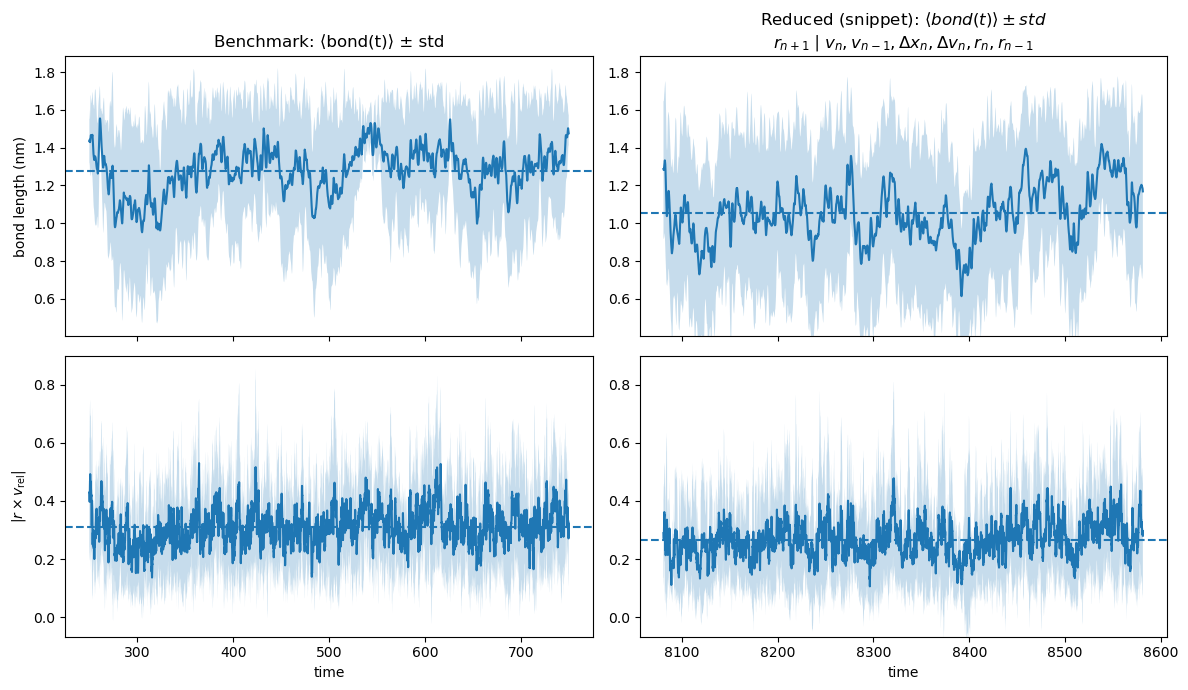

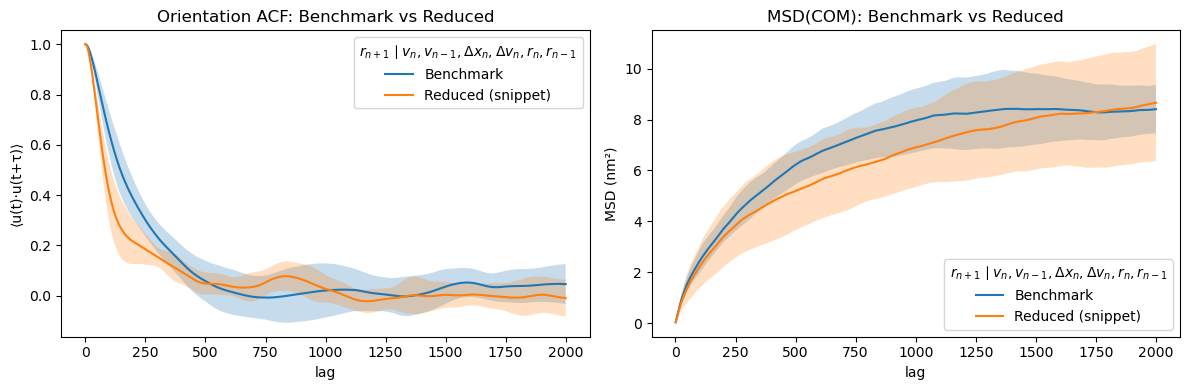

In [8]:
conditionedOn = "pipimdqidpiririm"
n_trajs = 10
bench_fileIDs = np.random.choice(2500, n_trajs, replace=False)
reduc_fileIDs = np.random.choice(100,  n_trajs, replace=False)

baseDirPath = "/group/ag_cmb/scratch/maojrs/stochasticClosure/"

A, B, figs = compare_dimer_h5_ensemble(
    bench_fileIDs,
    reduc_fileIDs,
    baseDirPath=baseDirPath,
    conditionedOn=conditionedOn,
    boxsize=5,
    max_lag=2000,
    reduced_plot_mode="snippet", # "snippet" (fair) or "full"
    random_seed=0
)

plt.show()

In [9]:
def plot_com_grid(
    com_A, com_B,
    N: int = 10,
    *,
    rng_seed: int | None = 0,
    idxA=None,
    idxB=None,
    title_prefix: str = "COM trajectory",
):
    """
    com_A, com_B: lists of arrays shaped (T,3) (or (T,2) also ok)
    N: number of rows (pairs) to plot
    idxA, idxB: optional index arrays/lists of length N to choose specific trajectories
               If omitted, chooses random indices (without replacement) from each set.
    Returns: fig
    """
    nA_tot = len(com_A)
    nB_tot = len(com_B)
    if nA_tot == 0 or nB_tot == 0:
        raise ValueError("com_A and com_B must be non-empty lists.")

    N = int(N)
    N = min(N, nA_tot, nB_tot)
    if N <= 0:
        raise ValueError("N must be >= 1 and <= min(len(com_A), len(com_B)).")

    rng = np.random.default_rng(rng_seed)

    if idxA is None:
        idxA = rng.choice(nA_tot, N, replace=False)
    else:
        idxA = np.asarray(idxA)
        if len(idxA) != N:
            raise ValueError("idxA must have length N.")

    if idxB is None:
        idxB = rng.choice(nB_tot, N, replace=False)
    else:
        idxB = np.asarray(idxB)
        if len(idxB) != N:
            raise ValueError("idxB must have length N.")

    fig, ax = plt.subplots(N, 2, figsize=(12, max(5 * N, 3.5)), sharex=False, sharey=False)

    # handle N=1 (matplotlib returns 1D axes)
    if N == 1:
        ax = np.array([ax])

    for row, (iA, iB) in enumerate(zip(idxA, idxB)):
        RA = com_A[int(iA)]
        RB = com_B[int(iB)]

        # allow either (T,3) or (T,2)
        xA, yA = RA[:, 0], RA[:, 1]
        xB, yB = RB[:, 0], RB[:, 1]

        ax[row, 0].plot(xA, yA, alpha=0.8)
        ax[row, 0].set_title(f"{title_prefix} — Benchmark (i={int(iA)})")
        ax[row, 0].set_xlabel("x (nm)")
        ax[row, 0].set_ylabel("y (nm)")
        ax[row, 0].axis("equal")

        ax[row, 1].plot(xB, yB, alpha=0.8)
        ax[row, 1].set_title(f"{title_prefix} — Reduced (i={int(iB)})")
        ax[row, 1].set_xlabel("x (nm)")
        ax[row, 1].set_ylabel("y (nm)")
        ax[row, 1].axis("equal")

    plt.tight_layout()
    return fig

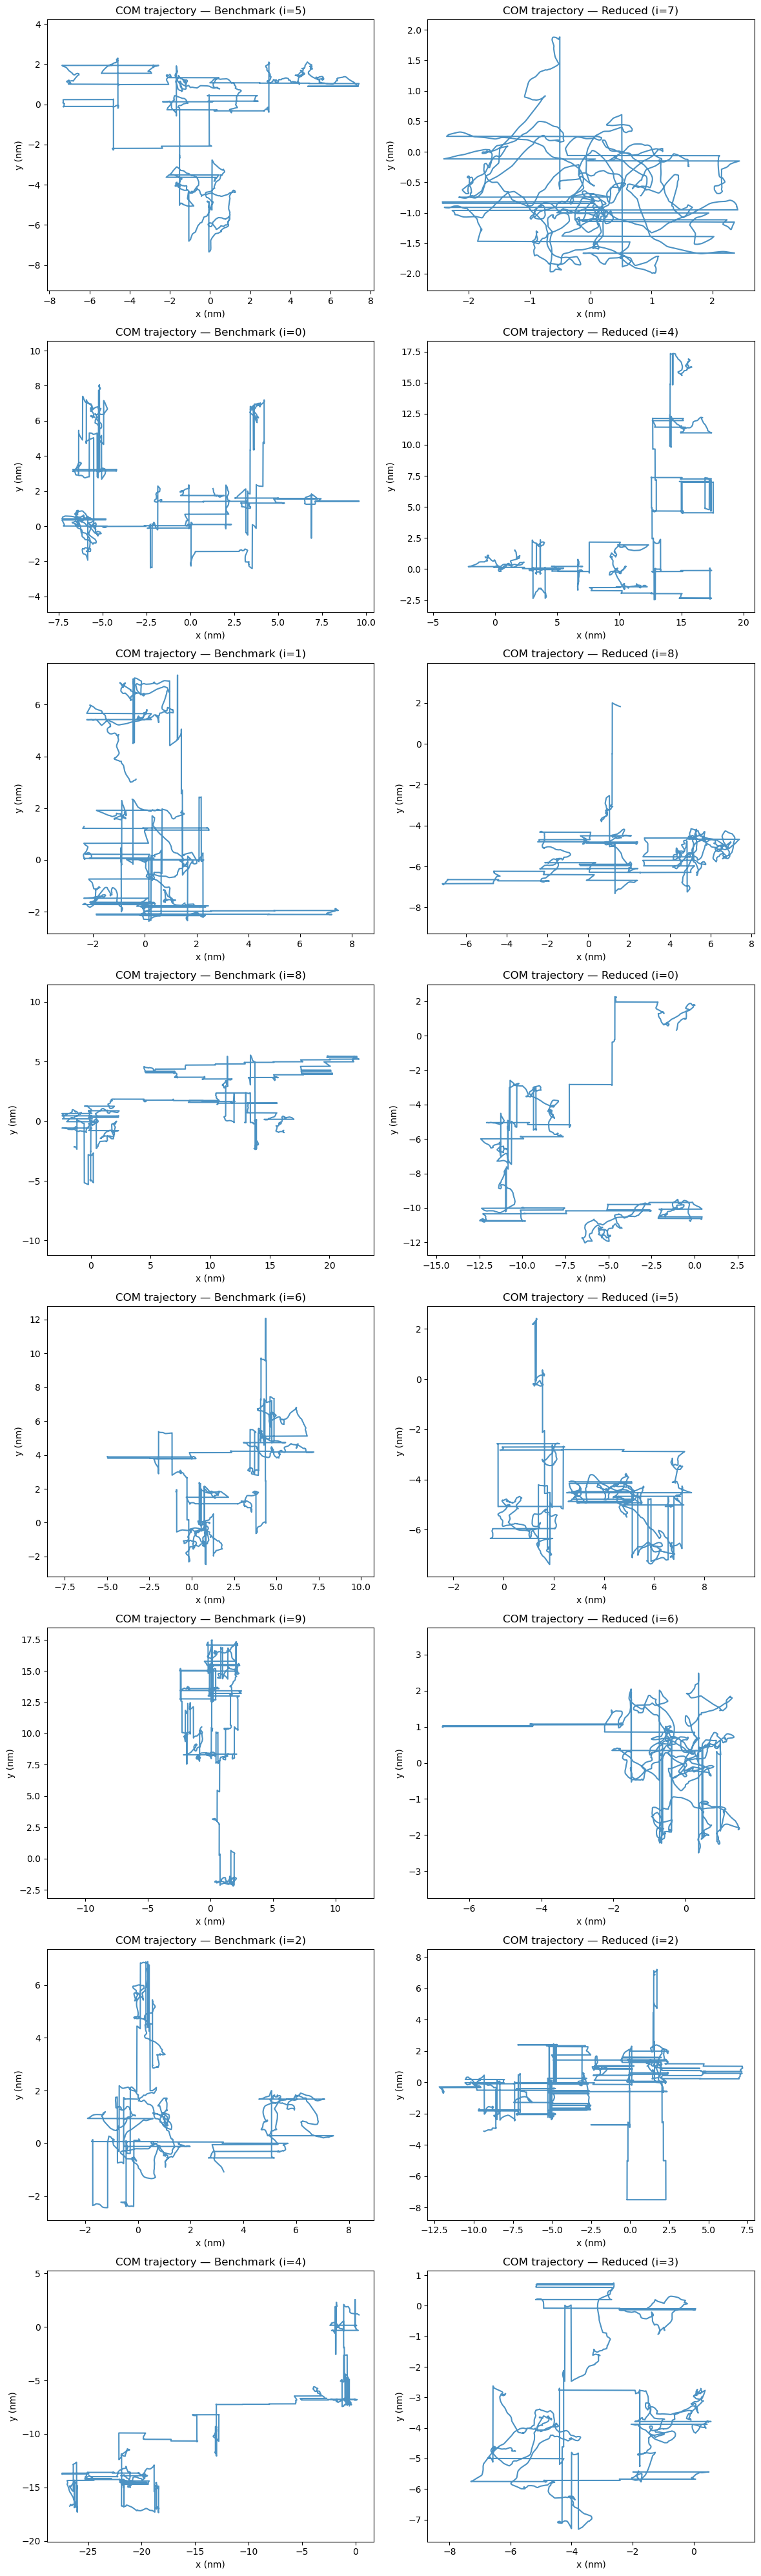

In [10]:
fig_grid = plot_com_grid(
    A["com_paths"], B["com_paths"],
    N=8,
    rng_seed=123
)
plt.show()

In [ ]:
# SCRAPS

In [11]:
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/dimer/boxsize5/benchmark/"

with h5py.File(localDirectory+"simMoriZwanzig_0100.h5", "r") as f:
    print(list(f.keys())) 
    print(f['msmrd_data'])

['msmrd_data']
<HDF5 dataset "msmrd_data": shape (20000, 11), type "<f8">


In [24]:
path = localDirectory + "simMoriZwanzig_0100.h5"

with h5py.File(path, "r") as f:
    X: np.ndarray = f["msmrd_data"][:]   # (20000, 11)
    
print("X shape:", X.shape, "dtype:", X.dtype, '\n')
print("first row:", X[0],'\n')
print("second row:", X[1], '\n')
print("time[0], time[1]:", X[0,0], X[1,0], '\n')

t = X[:, 0]
print("same time within pair fraction:", np.mean(t[0::2] == t[1::2]))
print("monotone across frames:", np.all(np.diff(t[0::2]) >= 0))

X shape: (20000, 11) dtype: float64 

first row: [ 2.50000000e+02  1.10333954e+00 -4.98305685e-01  6.77403620e-01
  4.87772279e-02  3.82454695e-02 -7.94498713e-02  1.00000000e+00
 -3.93920000e-03  6.02247401e-03  2.24155401e-03] 

second row: [ 2.50000000e+02  1.01303244e+00 -1.91121811e+00  5.47527157e-01
 -1.36625825e-01  1.09795311e-01  2.41739799e-01  1.00000000e+00
  6.00956890e-03 -2.30275469e-03 -2.92090515e-03] 

time[0], time[1]: 250.0000000000226 250.0000000000226 

same time within pair fraction: 1.0
monotone across frames: True


In [45]:
assert X.shape[0] % 2 == 0
T = X.shape[0] // 2

frames = torch.tensor(X.reshape(T, 2, 11))   # frame k contains both beads

In [46]:
t = frames[:, 0, 0]           # (T,) time from bead 1 (same as bead 2)
q = frames[:, :, 1:4]         # (T, 2, 3) positions
v = frames[:, :, 4:7]         # (T, 2, 3) velocities
mystery = frames[:, :, 7]     # (T, 2) the unknown scalar per bead
r = frames[:, :, 8:11]        # (T, 2, 3) your auxiliary vector

In [47]:
def dimer_minimal_image_bond(q: torch.Tensor,
                            boxsize=None,
                            boundary_type: str = "periodic",
                            bead0: int = 0,
                            bead1: int = 1):
    """
    q: [T, 2, 3] (or [..., 2, 3]) torch tensor of bead positions
    returns:
      rel:   [T, 3] minimal-image vector q[bead1] - q[bead0]
      bond:  [T]    minimal-image distance
    """
    if q.ndim < 2 or q.shape[-2] < 2 or q.shape[-1] != 3:
        raise ValueError(f"Expected q[..., 2, 3], got {tuple(q.shape)}")

    q1 = q[..., bead0, :]  # [..., 3]
    q2 = q[..., bead1, :]  # [..., 3]
    rel = q2 - q1          # [..., 3]

    if boundary_type == "periodic" and boxsize is not None:
        # Build box tensor on correct device/dtype
        if torch.is_tensor(boxsize):
            box = boxsize.to(device=rel.device, dtype=rel.dtype)
        elif isinstance(boxsize, (list, tuple, np.ndarray)):
            box = torch.as_tensor(boxsize, device=rel.device, dtype=rel.dtype)
        else:
            box = torch.full((3,), float(boxsize), device=rel.device, dtype=rel.dtype)

        # Ensure shape (3,)
        box = box.reshape(-1)
        if box.numel() == 1:
            box = box.repeat(3)
        elif box.numel() != 3:
            raise ValueError(f"boxsize must be scalar or length-3, got {box.numel()} elements")

        rel = rel - box * torch.round(rel / box)

    bond = torch.linalg.norm(rel, dim=-1)  # [...]
    return rel, bond


In [48]:
rel, bond = dimer_minimal_image_bond(q, boxsize=5.0)
bond_mean = bond.mean().item()
print("mean bond length:", bond_mean)

mean bond length: 1.3040442632262579


In [49]:
# using your original frames array or X
# If you already have frames: frames[T,2,11]
t0 = frames[:,0,0]
t1 = frames[:,1,0]
print("same time in pair:", (t0 == t1).float().mean().item())
print("dt mean:", (t0[1:] - t0[:-1]).mean().item())

same time in pair: 1.0
dt mean: 0.0499999999999843


In [50]:
b = bond.detach().cpu().numpy()
hist, edges = np.histogram(b, bins=60, range=(0, 2.2), density=True)
peak_idx = hist.argsort()[-3:][::-1]
print("top bin centers:", 0.5*(edges[peak_idx]+edges[peak_idx+1]))

top bin centers: [1.52166667 1.485      1.44833333]


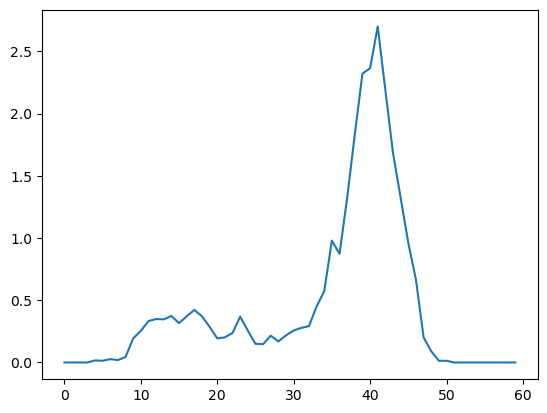

In [52]:
plt.plot(hist)

In [53]:
q_np = q.detach().cpu().numpy()          # (T,2,3) in nm
scale = 10.0                              # nm -> Å

with open("chimera_files/dimer.xyz", "w") as f:
    for k in range(q_np.shape[0]):
        f.write("2\n")
        f.write(f"frame {k}\n")
        for i, elem in enumerate(["C","C"]):
            x, y, z = q_np[k, i] * scale
            f.write(f"{elem} {x:.6f} {y:.6f} {z:.6f}\n")

In [56]:
R = 0.5 * (q[:,0,:] + q[:,1,:])     # (T,3)
rel, bond = dimer_minimal_image_bond(q, boxsize=5.0)
u = rel / bond[:, None]             # (T,3)

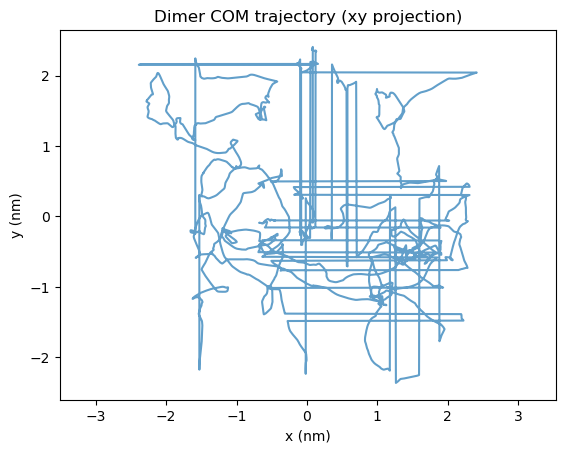

In [57]:
plt.figure()
plt.plot(R[:,0], R[:,1], alpha=0.7)
plt.xlabel("x (nm)")
plt.ylabel("y (nm)")
plt.title("Dimer COM trajectory (xy projection)")
plt.axis("equal")
plt.show()


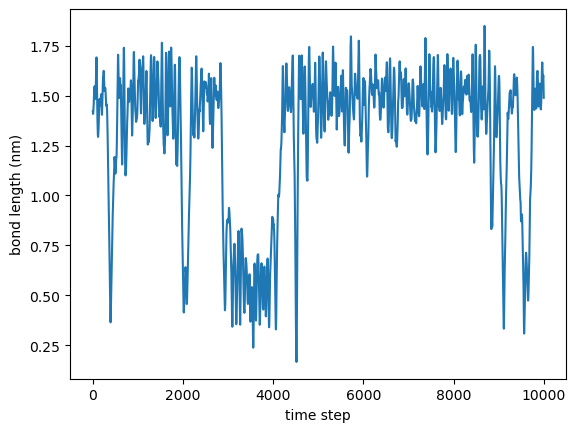

In [58]:
plt.figure()
plt.plot(bond)
plt.xlabel("time step")
plt.ylabel("bond length (nm)")
plt.show()

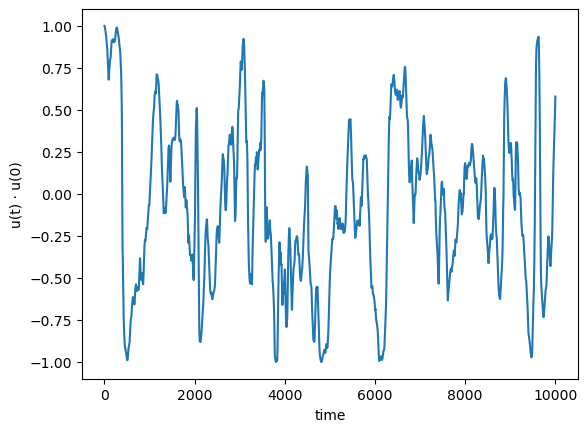

In [59]:
u0 = u[0]
corr = (u * u0).sum(axis=1)

plt.figure()
plt.plot(corr)
plt.xlabel("time")
plt.ylabel("u(t) · u(0)")
plt.show()